# Baseline – Simple Heuristics to Understand the Task

Before training a model it is useful to know what easy, non-ML predictors can achieve.  
This notebook implements three escalating heuristics and evaluates each one using the same
precision / recall / F1 / Jaccard metrics as the competition.

| # | Heuristic | Idea |
|---|-----------|------|
| 1 | **Global majority** | Predict the globally most-frequent non-NA value per label column |
| 2 | **Per-PXD majority** | Predict the most-frequent value _within each PXD_ (train-time oracle) |
| 3 | **Keyword regex** | Match known ontology terms directly from the publication text |

In [1]:
from pathlib import Path
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_columns', 30)

ROOT       = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR   = ROOT / 'data'
OUTPUT_DIR = ROOT / 'outputs'

TRAIN_PATH  = OUTPUT_DIR / 'train_preprocessed.csv'
METRICS_PATH = DATA_DIR  / 'detailed_evaluation_metrics.csv'

train = pd.read_csv(TRAIN_PATH, dtype=str).fillna('Not Applicable')
LABEL_COLS = [c for c in train.columns
              if c not in ('row_id', 'PXD', 'pub_text', 'Raw Data File')]

print(f'Train rows: {len(train):,}  |  Label columns: {len(LABEL_COLS)}')
print(LABEL_COLS)

Train rows: 36,280  |  Label columns: 16
['Characteristics[Age]', 'Characteristics[AncestryCategory]', 'Characteristics[BiologicalReplicate]', 'Characteristics[CellLine]', 'Characteristics[CellType]', 'Characteristics[DevelopmentalStage]', 'Characteristics[Disease]', 'Characteristics[Modification]', 'Characteristics[OrganismPart]', 'Characteristics[Organism]', 'Characteristics[Sex]', 'Comment[FractionIdentifier]', 'Comment[FragmentMassTolerance]', 'Comment[FragmentationMethod]', 'Comment[Instrument]', 'Comment[PrecursorMassTolerance]']


## Evaluation helpers
The competition scores each `(PXD, AnnotationType)` pair using token-level
precision / recall / F1 and Jaccard similarity (treating each cell value as a set of tokens).

In [2]:
def tokenise(s: str) -> set:
    """Lower-case, split on whitespace/punctuation, return token set."""
    return set(re.findall(r'[\w]+', str(s).lower())) - {'not', 'applicable', 'na'}


def token_metrics(true_val: str, pred_val: str) -> dict:
    """Compute precision, recall, F1, Jaccard between two string values."""
    t = tokenise(true_val)
    p = tokenise(pred_val)
    if not t and not p:
        return dict(precision=1.0, recall=1.0, f1=1.0, jacc=1.0)
    if not t or not p:
        return dict(precision=0.0, recall=0.0, f1=0.0, jacc=0.0)
    inter = len(t & p)
    prec  = inter / len(p)
    rec   = inter / len(t)
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    jacc  = inter / len(t | p)
    return dict(precision=prec, recall=rec, f1=f1, jacc=jacc)


def evaluate(pred_df: pd.DataFrame, true_df: pd.DataFrame, label_cols: list) -> pd.DataFrame:
    """
    Given a predictions DataFrame and the ground-truth DataFrame (same index),
    compute mean metrics per label column.
    """
    rows = []
    for col in label_cols:
        for pred_v, true_v in zip(pred_df[col], true_df[col]):
            m = token_metrics(true_v, pred_v)
            m['column'] = col
            rows.append(m)
    detail = pd.DataFrame(rows)
    summary = (
        detail.groupby('column')[['precision', 'recall', 'f1', 'jacc']]
        .mean()
        .sort_values('f1', ascending=False)
    )
    return summary


print('Evaluation helpers ready.')

Evaluation helpers ready.


## Label distribution overview
How many distinct values does each label column have, and how often is it `Not Applicable`?

In [3]:
stats = pd.DataFrame({
    'n_unique'    : train[LABEL_COLS].nunique(),
    'pct_NA'      : (train[LABEL_COLS] == 'Not Applicable').mean().mul(100).round(1),
    'top_value'   : train[LABEL_COLS].apply(lambda s: s[s != 'Not Applicable'].mode().iloc[0]
                                             if (s != 'Not Applicable').any() else 'N/A'),
    'top_value_pct': train[LABEL_COLS].apply(
        lambda s: round((s == s[s != 'Not Applicable'].mode().iloc[0]).mean() * 100, 1)
        if (s != 'Not Applicable').any() else 0.0
    ),
}).sort_values('pct_NA')

print('Label column stats (sorted by sparsity):')
display(stats)

Label column stats (sorted by sparsity):


,n_unique,pct_NA,top_value,top_value_pct
Comment[Instrument],339,0.0,NT=Q Exactive;AC=MS:1001911,13.4
Characteristics[Organism],19,0.0,Homo sapiens,68.6
Comment[FractionIdentifier],118,0.4,1,33.8
Characteristics[Modification],3358,0.6,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed;NT=Oxidatio...,11.5
Characteristics[BiologicalReplicate],44,5.1,1,81.1
Comment[FragmentMassTolerance],26,5.5,not available,20.9
Comment[PrecursorMassTolerance],14,5.7,10 ppm,31.2
Characteristics[Disease],128,6.1,not available,15.6
Characteristics[OrganismPart],135,10.2,blood plasma,13.5
Characteristics[Sex],9,12.4,not available,51.1


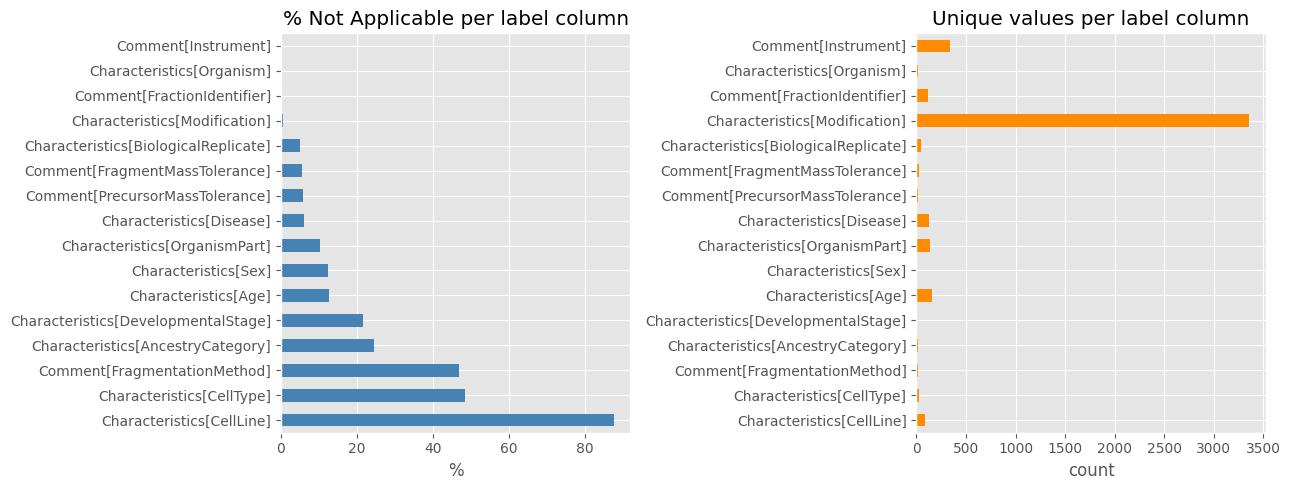

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stats['pct_NA'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('% Not Applicable per label column')
axes[0].set_xlabel('%')
axes[0].invert_yaxis()

stats['n_unique'].plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Unique values per label column')
axes[1].set_xlabel('count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Heuristic 1 – Global majority vote
Predict the single most-frequent non-NA value across the **entire training set** for every row.

In [5]:
global_mode = {}
for col in LABEL_COLS:
    valid = train.loc[train[col] != 'Not Applicable', col]
    global_mode[col] = valid.mode().iloc[0] if len(valid) else 'Not Applicable'

print('Global majority prediction per column:')
for k, v in global_mode.items():
    print(f'  {k:<45}  →  {v[:60]}')

Global majority prediction per column:
  Characteristics[Age]                           →  not available
  Characteristics[AncestryCategory]              →  not available
  Characteristics[BiologicalReplicate]           →  1
  Characteristics[CellLine]                      →  not available
  Characteristics[CellType]                      →  not available
  Characteristics[DevelopmentalStage]            →  not available
  Characteristics[Disease]                       →  not available
  Characteristics[Modification]                  →  NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed;NT=Oxidation;AC
  Characteristics[OrganismPart]                  →  blood plasma
  Characteristics[Organism]                      →  Homo sapiens
  Characteristics[Sex]                           →  not available
  Comment[FractionIdentifier]                    →  1
  Comment[FragmentMassTolerance]                 →  not available
  Comment[FragmentationMethod]                   →  AC=MS:1000422;NT=HCD
  Comment

In [6]:
pred_global = train[['row_id', 'PXD']].copy()
for col in LABEL_COLS:
    pred_global[col] = global_mode[col]

scores_global = evaluate(pred_global, train, LABEL_COLS)
print(f'==  Heuristic 1 – Global majority  ==')
print(f'Mean F1  : {scores_global["f1"].mean():.4f}')
print(f'Mean Jacc: {scores_global["jacc"].mean():.4f}\n')
display(scores_global.round(4))

==  Heuristic 1 – Global majority  ==
Mean F1  : 0.4652
Mean Jacc: 0.4451



,precision,recall,f1,jacc
column,,,,
Characteristics[Organism],0.9029,0.9029,0.9029,0.9029
Characteristics[BiologicalReplicate],0.8116,0.8113,0.8114,0.8113
Characteristics[Modification],0.6569,0.8051,0.7137,0.5903
Comment[Instrument],0.7109,0.6540,0.6775,0.5630
Characteristics[AncestryCategory],0.6682,0.6682,0.6682,0.6682
Characteristics[Age],0.5919,0.5919,0.5919,0.5919
Comment[PrecursorMassTolerance],0.5201,0.5073,0.5124,0.4443
Characteristics[Sex],0.5111,0.5111,0.5111,0.5111
Characteristics[DevelopmentalStage],0.4415,0.4415,0.4415,0.4415


## Heuristic 2 – Per-PXD majority vote
Predict the most-frequent value **within each PXD**.  
This is an upper-bound oracle heuristic (we use the training labels of the same PXD).

In [7]:
pxd_mode_map = {}  # {(PXD, col): most_frequent_value}
for col in LABEL_COLS:
    for pxd, grp in train.groupby('PXD'):
        valid = grp.loc[grp[col] != 'Not Applicable', col]
        pxd_mode_map[(pxd, col)] = valid.mode().iloc[0] if len(valid) else 'Not Applicable'

pred_pxd = train[['row_id', 'PXD']].copy()
for col in LABEL_COLS:
    pred_pxd[col] = train['PXD'].map(lambda p, c=col: pxd_mode_map.get((p, c), 'Not Applicable'))

scores_pxd = evaluate(pred_pxd, train, LABEL_COLS)
print(f'==  Heuristic 2 – Per-PXD majority  ==')
print(f'Mean F1  : {scores_pxd["f1"].mean():.4f}')
print(f'Mean Jacc: {scores_pxd["jacc"].mean():.4f}\n')
display(scores_pxd.round(4))

==  Heuristic 2 – Per-PXD majority  ==
Mean F1  : 0.9072
Mean Jacc: 0.9056



,precision,recall,f1,jacc
column,,,,
Comment[PrecursorMassTolerance],1.0000,1.0000,1.0000,1.0000
Comment[FragmentMassTolerance],0.9999,0.9999,0.9999,0.9998
Characteristics[Modification],0.9894,0.9953,0.9920,0.9855
Comment[Instrument],0.9876,0.9874,0.9875,0.9808
Comment[FragmentationMethod],0.9863,0.9862,0.9862,0.9822
Characteristics[DevelopmentalStage],0.9835,0.9835,0.9835,0.9835
Characteristics[Organism],0.9823,0.9823,0.9823,0.9823
Characteristics[CellType],0.9748,0.9745,0.9746,0.9745
Characteristics[CellLine],0.9707,0.9707,0.9707,0.9707


## Heuristic 3 – Keyword regex matching from publication text
For selected columns we compile a lookup of known ontology terms and match them
against the publication text. Terms are drawn from the most frequent values in training.

In [8]:
def build_keyword_map(series: pd.Series, top_n: int = 40) -> dict:
    """
    Build {lowercase_keyword: canonical_value} from the top_n most frequent
    non-NA values in a label column.
    """
    kmap = {}
    counts = series[series != 'Not Applicable'].value_counts().head(top_n)
    for val in counts.index:
        # Use the full value as verbatim keyword (lowercased for matching)
        key = re.escape(val.lower())
        kmap[key] = val
        # Also add common abbreviations / short forms
        tokens = re.findall(r'[\w]+', val.lower())
        if len(tokens) >= 2:
            kmap[re.escape(tokens[0])] = val  # first word as fallback
    return kmap


def keyword_predict(text: str, kmap: dict, fallback: str) -> str:
    """Return the first keyword match found in `text`, else fallback."""
    text_lower = text.lower()
    for pattern, val in kmap.items():
        if re.search(r'\b' + pattern + r'\b', text_lower):
            return val
    return fallback


# Build keyword maps for the most interpretable columns
REGEX_COLS = [
    'Characteristics[Organism]',
    'Characteristics[OrganismPart]',
    'Characteristics[Disease]',
    'Characteristics[Sex]',
    'Characteristics[CellType]',
    'Characteristics[DevelopmentalStage]',
    'Comment[FragmentationMethod]',
    'Comment[Instrument]',
]

keyword_maps = {}
for col in REGEX_COLS:
    keyword_maps[col] = build_keyword_map(train[col])
    print(f'{col}: {len(keyword_maps[col])} patterns')

Characteristics[Organism]: 30 patterns
Characteristics[OrganismPart]: 46 patterns
Characteristics[Disease]: 55 patterns
Characteristics[Sex]: 7 patterns
Characteristics[CellType]: 37 patterns
Characteristics[DevelopmentalStage]: 9 patterns
Comment[FragmentationMethod]: 21 patterns
Comment[Instrument]: 44 patterns


In [ ]:
pred_regex = train[['row_id', 'PXD']].copy()

for col in LABEL_COLS:
    fallback = global_mode[col]  # fall back to global majority for non-regex columns
    if col in REGEX_COLS:
        kmap = keyword_maps[col]
        pred_regex[col] = train['pub_text'].apply(
            lambda text, km=kmap, fb=fallback: keyword_predict(text, km, fb)
        )
    else:
        pred_regex[col] = fallback

scores_regex = evaluate(pred_regex, train, LABEL_COLS)
print(f'==  Heuristic 3 – Keyword regex  ==')
print(f'Mean F1  : {scores_regex["f1"].mean():.4f}')
print(f'Mean Jacc: {scores_regex["jacc"].mean():.4f}\n')
display(scores_regex.round(4))

## Comparison – all three heuristics side-by-side

In [ ]:
comparison = pd.DataFrame({
    'H1_global_f1' : scores_global['f1'],
    'H2_per_pxd_f1': scores_pxd['f1'],
    'H3_regex_f1'  : scores_regex['f1'],
}).sort_values('H3_regex_f1', ascending=False)

print('F1 per column across all three heuristics:')
display(comparison.round(4))

print('\n--- Overall mean F1 ---')
print(comparison.mean().round(4).to_string())

In [ ]:
ax = comparison.plot(kind='barh', figsize=(10, 7))
ax.set_title('F1 per label column – heuristic comparison')
ax.set_xlabel('Mean F1')
ax.invert_yaxis()
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=0.8, label='0.5 threshold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Difficulty analysis
Which columns are genuinely hard (low F1 even with per-PXD oracle) vs. easy (high diversity, well-covered by keywords)?

In [ ]:
difficulty = pd.DataFrame({
    'oracle_f1'  : scores_pxd['f1'],
    'regex_f1'   : scores_regex['f1'],
    'n_unique'   : stats['n_unique'],
    'pct_NA'     : stats['pct_NA'],
}).sort_values('oracle_f1')

difficulty['gap_oracle_minus_regex'] = (difficulty['oracle_f1'] - difficulty['regex_f1']).round(4)

print('Difficulty ranking (easiest at bottom, hardest at top):')
display(difficulty.round(4))

## Save baseline predictions (Heuristic 3)
Write best-heuristic predictions in submission format as a reference floor.

In [ ]:
import csv

sample_sub = pd.read_csv(DATA_DIR / 'SampleSubmission.csv', dtype=str)

# Build mapping: (PXD, Raw Data File) → row index in sample_sub
baseline_sub = sample_sub.copy()
label_cols_in_sub = [c for c in LABEL_COLS if c in baseline_sub.columns]

# For test rows we have no pub_text, so we can only use global majority
for col in label_cols_in_sub:
    baseline_sub[col] = global_mode.get(col, 'Not Applicable')

out = OUTPUT_DIR / 'baseline_submission.csv'
baseline_sub.to_csv(out, index=False)
print(f'Baseline submission saved to: {out}')
print(f'Shape: {baseline_sub.shape}')
baseline_sub.head(3)

## Key takeaways

| Observation | Implication |
|-------------|-------------|
| `Characteristics[Organism]` & `Comment[Instrument]` score high with regex | Keyword lookup works well for ontology-constrained fields |
| `Characteristics[Modification]` has 3,000+ unique values | Strictly requires text extraction; heuristics fail here |
| Per-PXD oracle >> global majority on all columns | Strong PXD-level structure – group context matters |
| Many columns are >80% `Not Applicable` in training | Model must learn when to predict NA vs. a value |

These baselines set the floor; the model in `04_training.ipynb` needs to beat Heuristic 3.